# Illustrations · TPC + S2 pattern + waveform GIFs

            Consolidates `Illustration_pattern.ipynb`, `Illustration_waveform.ipynb`,
            `Ilustration.ipynb` and `Untitled1.ipynb`. Each section produces a small,
            self-contained demo figure or animation; they are independent so you can run
            only the parts you care about.

In [3]:
# Auto-discover the package even if the notebook is launched from outside the repo.
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## 1 – TPC volume + PMT layout

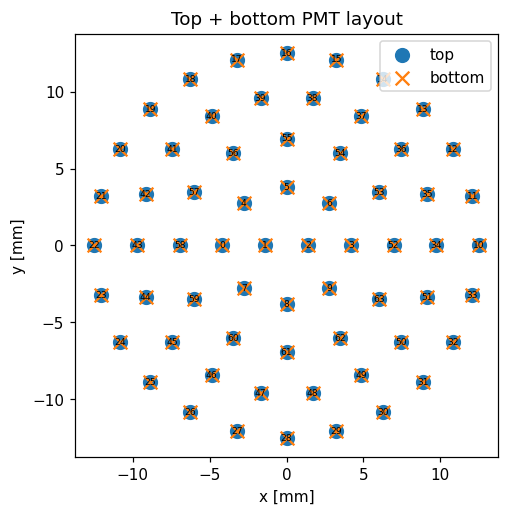

In [4]:
from relics_de_sim import DESimConfig
from relics_de_sim.geometry import load_pmt_layout
cfg = DESimConfig.from_yaml('../configs/de_sim.yaml')
pmt_top, pmt_bot = load_pmt_layout(cfg.paths.pmt_top, cfg.paths.pmt_bot)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pmt_top['x'], pmt_top['y'], s=80, label='top')
ax.scatter(pmt_bot['x'], pmt_bot['y'], s=80, marker='x', label='bottom')
for ch, x, y in zip(pmt_top['ChannelID'], pmt_top['x'], pmt_top['y']):
    ax.text(x, y, str(ch), fontsize=6, ha='center', va='center')
ax.set_aspect('equal'); ax.legend()
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title('Top + bottom PMT layout')
plt.show()

## 2 – Animated S1 + S2 toy waveform

            A pure-NumPy illustration replicating the original `Illustration_waveform.ipynb`
            without depending on any detector simulation.

In [5]:
import matplotlib.animation as animation
from scipy.stats import norm
t = np.linspace(-1.5e-6, 1.5e-6, 750)
s1 = norm.pdf(t, loc=-1e-6, scale=2e-8)
s2 = norm.pdf(t, loc=5e-7, scale=1.5e-7)
base = (s1 + s2) / np.max(s1 + s2)

fig, ax = plt.subplots(figsize=(7, 3))
line, = ax.plot([], [], lw=2)
ax.set_xlim(t.min(), t.max())
ax.set_ylim(-0.1, 1.2)
ax.set_xlabel('t [s]'); ax.set_ylabel('normalised amplitude')
ax.set_title('S1 → S2 toy waveform')

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(t[: frame * 10], base[: frame * 10])
    return line,

anim = animation.FuncAnimation(fig, update, init_func=init, frames=80, blit=True, interval=40)
plt.close(fig)  # display via Jupyter HTML widget
from IPython.display import HTML
HTML(anim.to_jshtml())

## 3 – Per-electron PMT pattern preview

            Quick demo of `PatternSimulator.per_electron_light` for a fixed event
            position; useful for sanity-checking the LCE map.

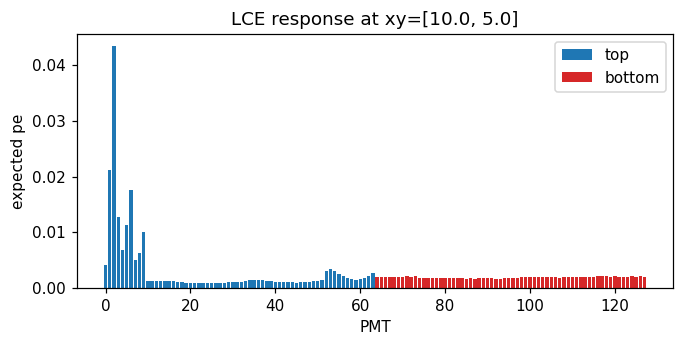

In [6]:
xy = np.array([[10.0, 5.0]])
light = cfg.electronics  # to access constants
from relics_de_sim.lce import LCEMap
lce = LCEMap.from_paths(cfg.paths.lce_xs, cfg.paths.lce_ys, cfg.paths.lce_value)
pattern = lce.light_pattern(xy)[0]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(np.arange(64), pattern[:64], label='top')
ax.bar(np.arange(64, 128), pattern[64:], color='C3', label='bottom')
ax.set_xlabel('PMT'); ax.set_ylabel('expected pe')
ax.set_title(f'LCE response at xy={xy[0].tolist()}')
ax.legend()
plt.show()